In [1]:
import sys
from pathlib import Path
# add project root to path
project_root = Path.cwd().parent  # assuming you're running from Notebooks/
sys.path.append(str(project_root))

In [2]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from gan.models import Generator, Discriminator
from gan.training import train_gan

In [3]:


def make_gaussian_mixture(
    n_samples=50_000,
    centers=8,
    radius=5.0,
    std=0.5,
    seed=0
):
    """
    Create distribution of disk-like clusters centered at the origin
    Parameters
    ----------
    n_samples : int
        number of data points to be created
    centers : int   
        number of clusters to have
    radius : float
        distance to origin of cluster centers
    std : float
        standard deviation of distance of points to cluster center
    seed : int
        random seed
    Returns
    -------
    tuple(np.ndarray)
        array of points, array of centers for each point, array of labels for each point
    """
    rng = np.random.default_rng(seed)

    angles = np.linspace(0, 2*np.pi, centers, endpoint=False)
    means = np.stack([
        radius * np.cos(angles),
        radius * np.sin(angles)
    ], axis=1)

    samples = []
    sample_labels = []
    sample_centers = []
    for _ in range(n_samples):
        k = rng.integers(0, centers)
        sample_labels.append(k)
        sample_centers.append(means[k])
        x = rng.normal(loc=means[k], scale=std, size=2)
        samples.append(x)

    return np.array(samples, dtype=np.float32), np.array(sample_labels), np.array(sample_centers,dtype=np.float32)

In [4]:

# Create data and labels and points
X, c_label, c_center = make_gaussian_mixture()

In [5]:
# one hot encode the labels
one_hot = torch.nn.functional.one_hot(torch.tensor(c_label), num_classes=8).float()

In [6]:
# combine the centers and labels into one conditional vector
c = torch.cat([torch.tensor(c_center), one_hot], dim=1)

In [7]:
G = Generator(
    noise_dim = 2,
    num_hidden_layers = 2,
    out_dim = 2,
    hidden_dims=(128,128),
    use_conditional=True,
    conditional_dim=c.shape[1]
)

In [8]:
D = Discriminator(
    feature_dim=2,
    num_hidden_layers=2,
    hidden_dims=(128,128),
    use_conditional=True,
    conditional_dim=c.shape[1]
)

In [9]:
train_gan(
    X=torch.tensor(X),
    G=G,
    D=D,
    c=c
)

Epoch 10/200 | D: 1.3863 | G: 0.6933
Epoch 20/200 | D: 1.3863 | G: 0.6933
Epoch 30/200 | D: 1.3863 | G: 0.6934
Epoch 40/200 | D: 1.3863 | G: 0.6932
Epoch 50/200 | D: 1.3863 | G: 0.6932
Epoch 60/200 | D: 1.3863 | G: 0.6931
Epoch 70/200 | D: 1.3863 | G: 0.6931
Epoch 80/200 | D: 1.3863 | G: 0.6933
Epoch 90/200 | D: 1.3863 | G: 0.6933
Epoch 100/200 | D: 1.3863 | G: 0.6934
Epoch 110/200 | D: 1.3863 | G: 0.6933
Epoch 120/200 | D: 1.3863 | G: 0.6932
Epoch 130/200 | D: 1.3863 | G: 0.6932
Epoch 140/200 | D: 1.3863 | G: 0.6933
Epoch 150/200 | D: 1.3863 | G: 0.6932
Epoch 160/200 | D: 1.3863 | G: 0.6932
Epoch 170/200 | D: 1.3863 | G: 0.6932
Epoch 180/200 | D: 1.3863 | G: 0.6931
Epoch 190/200 | D: 1.3863 | G: 0.6932
Epoch 200/200 | D: 1.3863 | G: 0.6930


In [10]:

@torch.no_grad()
def plot_samples(G, X_real,c = None, n=2000, title=None):
    """
    plot fake and real points
    Parameters
    ----------
    G: Generator
        used to create fake points
    X_real: np.ndarray
        array of real data
    c : torch.Tensor | None
        if not none , the conditional to be used
    n: int
        nmber of points to be generated
    title : str | None
        optional string to be used for title of plot
    """
    if c is not None:
        c_input = c[:n]
    else: 
        c_input = None
    X_fake = G.generate(n, c_input).cpu().numpy()
    plt.figure(figsize=(5,5))
    plt.scatter(X_real[:n,0], X_real[:n,1], s=5, alpha=0.3, label="Real")
    plt.scatter(X_fake[:,0], X_fake[:,1], s=5, alpha=0.3, label="Fake")
    if title is not None:
        plt.title(title)
    plt.legend()
    plt.axis("equal")
    plt.show()

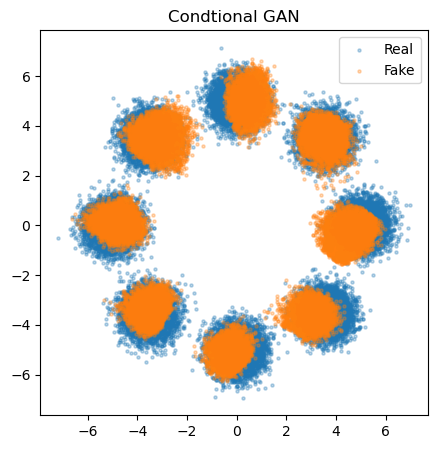

In [11]:
plot_samples(G, X, c, len(X), "Condtional GAN")